## Objective

The goal of this project is to build a machine learning model that predicts whether a loan application will be approved based on applicant information such as income, credit history, and loan amount.

This helps financial institutions reduce risk and make better lending decisions.

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load Dataset

In [22]:
df = pd.read_csv('loan_data_set.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [29]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


- The dataset contains 614 rows and 13 columns.

## 4. Handle Missing Values (CRITICAL STEP)

In [32]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Missing values in numerical columns were filled using the mean, while categorical columns were filled using the mode to preserve the most frequent category.

This ensures minimal distortion in data distribution.

In [35]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [36]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## 5. EDA

## Example 1: Loan Status Distribution

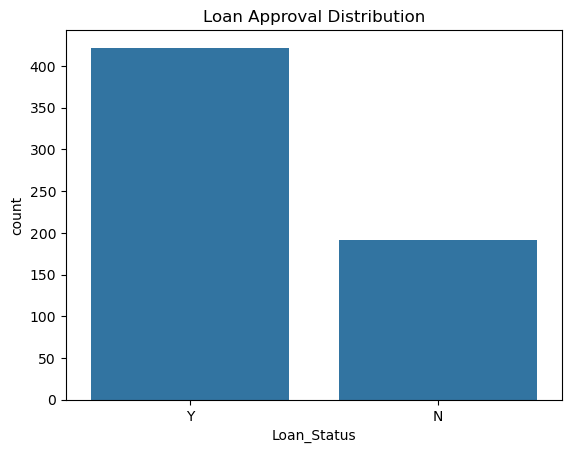

In [37]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

**Insight:**

- Check if dataset is balanced or not

## Example 2: Income vs Loan

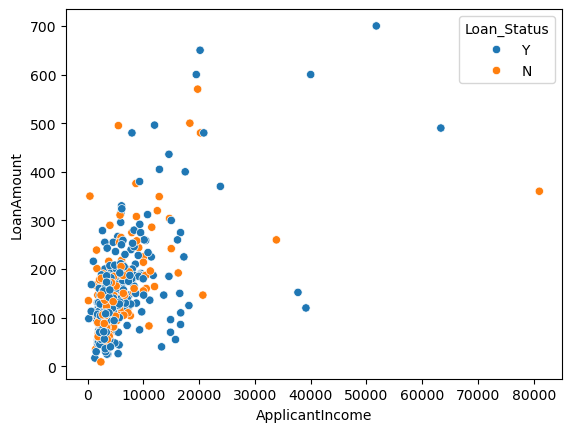

In [39]:
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', data=df)
plt.show()

**Insight:**
- High loan + low income → risky
- Applicants with higher income tend to have higher loan amounts approved, but some low-income applicants are also approved, indicating that other factors such as credit history play a significant role.
- Credit history is the most influential factor in loan approval. Applicants with a positive credit history are significantly more likely to have their loans approved.

## Business Insights

- Applicants with strong credit history are low risk.
- Income alone is not sufficient to determine loan approval.
- Loan approval decisions depend on multiple combined factors.

## Example 3: Education Impact

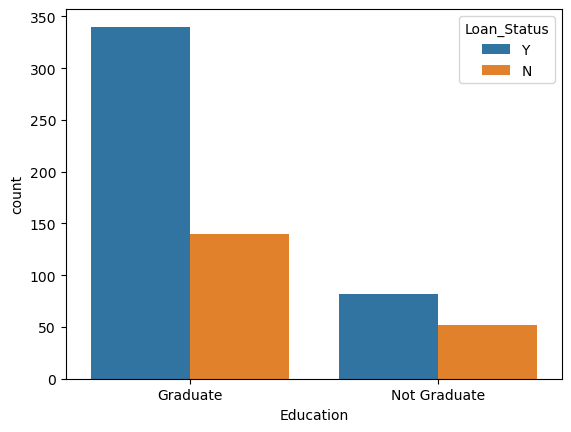

In [41]:
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.show()

### Average Feature Values by Loan Status

In [68]:
df.groupby('Loan_Status').mean()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_Status,,,,,,,,,,,,
0,303.406250,0.807292,0.588542,0.729167,0.270833,0.135417,5446.078125,1877.807292,150.945488,344.56250,0.572917,1.000000
1,307.907583,0.822275,0.682464,0.751185,0.194313,0.132701,5384.068720,1504.516398,144.349606,341.43128,0.983412,1.054502


## Grouped Analysis by Loan Status

- Applicants with approved loans generally have higher credit history values.
- Loan amount and applicant income show variation between approved and rejected groups.
- Credit history clearly plays a major role in loan approval decisions.

## 6. Encode Categorical Data

In [42]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

## 7. Split Data

In [47]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Train Models

### Logistic Regression

In [57]:
lr = LogisticRegression(max_iter=7000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Decision Tree

In [59]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

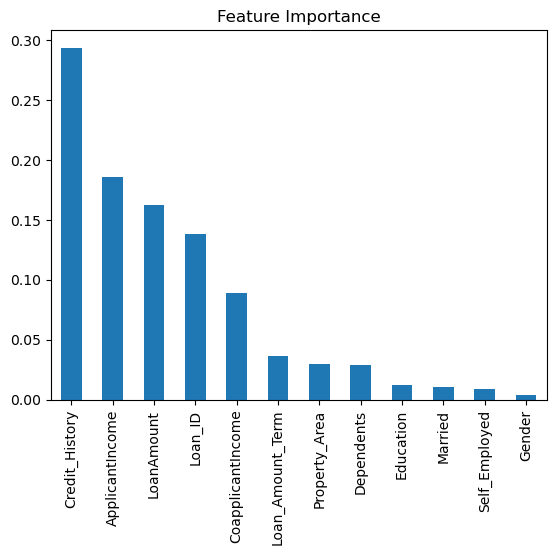

In [65]:
importances = dt.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', title='Feature Importance')
plt.show()

- Credit_History highest
- Income / LoanAmount moderate

## 9. Evaluation

In [60]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.7886178861788617
Decision Tree Accuracy: 0.7154471544715447


Logistic Regression provides more stable and generalizable results, while Decision Tree may overfit the training data.

Therefore, Logistic Regression is preferred for this problem.

### Confusion Matrix

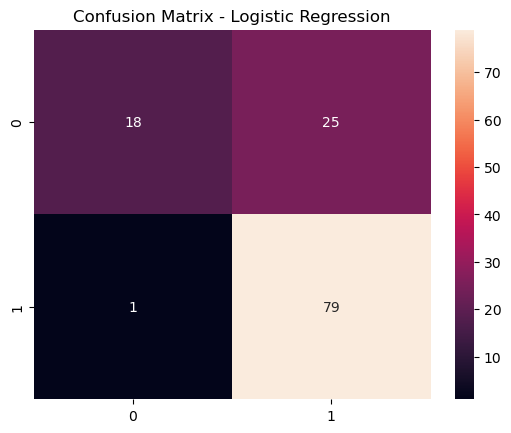

In [61]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows that the model correctly predicts most approved loans, but some misclassifications occur where approved loans are predicted as rejected.

This indicates room for improvement in reducing false negatives.

### Classification Report

In [63]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



## Conclusion

- Credit history is the most important factor in loan approval.
- Logistic Regression provides more stable and reliable predictions compared to Decision Tree.
- While income and loan amount influence decisions, they are not the sole determinants.
- Machine learning models can significantly assist financial institutions in reducing loan default risk.

This project demonstrates how data-driven approaches can improve decision-making in the banking sector.